In [1]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"✓ Project root added to path: {project_root}")

✓ Project root added to path: c:\Users\teMelkishi\Desktop\projects\tenx\projects\fintech-review-analytics


# Task 2: Sentiment and Thematic Analysis Pipeline

## Objective
Quantify review sentiment and identify recurring themes to uncover satisfaction drivers and pain points for each bank.

## Overview
This notebook implements a modular pipeline to:
1. **Sentiment Analysis**: Classify reviews as positive, negative, or neutral using DistilBERT
2. **Thematic Analysis**: Extract keywords using TF-IDF and group into business-relevant themes
3. **Aggregation**: Summarize sentiment by bank and star rating
4. **Output**: Generate CSV with review_id, review_text, sentiment_label, sentiment_score, identified_theme

## Tool Selection Rationale
- **DistilBERT**: Fast transformer model with good contextual understanding and high accuracy
- **TF-IDF**: Lightweight keyword extraction for theme discovery
- **spaCy/NLTK**: Robust tokenization and preprocessing
- **Zero-shot Classification**: Optional fallback for theme assignment

## Data Sources
- BOA Bank: `data/processed/boa_reviews_cleaned.csv`
- CBE Bank: `data/processed/cbe_reviews_cleaned.csv`
- Dashen Bank: `data/processed/dashen_reviews_cleaned.csv` (if available)

## Key Performance Indicators (KPIs)
- Sentiment scores assigned to 90%+ of reviews
- 2-3+ distinct themes per bank with keyword examples
- Modular, reusable code with documented logic

In [ ]:
# Import Required Libraries
import pandas as pd
from pathlib import Path
import warnings
import logging
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from src.load_data import load_cleaned_data
from src.sentiment_analysis import (
    explore_data,
    download_nltk_resources,
    initialize_sentiment_model,
    load_spacy_model,
    apply_sentiment_analysis,
    aggregate_sentiment_by_bank,
    aggregate_sentiment_by_rating,
    sentiment_distribution_by_bank,
    sentiment_distribution_by_rating,
    generate_theme_summary,
    generate_kpi_report
)
from src.text_preprocessing import (
    preprocess_text,
    extract_keywords_tfidf,
    define_themes,
    assign_themes_to_dataframe,
    prepare_results_dataframe,
    save_results_to_csv,
)

# Suppress warnings
warnings.filterwarnings("ignore")

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Section 1: Load and Explore Cleaned Data
Read cleaned review CSV files from the data/processed folder for all 3 banks. Display basic statistics, data shape, and sample reviews. Document data sources and any preprocessing notes.

In [3]:
banks_data, available_banks = load_cleaned_data()
print(f"\n📊 Available Banks: {available_banks}")
print(f"📦 Total datasets loaded: {len(banks_data)}")

INFO:src.load_data:✓ Loaded BOA Bank: 700 reviews
INFO:src.load_data:✓ Loaded CBE Bank: 1000 reviews
INFO:src.load_data:✓ Loaded Dashen Bank: 1000 reviews



📊 Available Banks: ['BOA Bank', 'CBE Bank', 'Dashen Bank']
📦 Total datasets loaded: 3


## Section 2: Initialize Sentiment Analysis Models
Load the DistilBERT transformer model with error handling and fallback to VADER. Configure the sentiment pipeline and initialize NLTK data dependencies.


In [4]:
# Initialize models
download_nltk_resources(logger)
sentiment_model = initialize_sentiment_model(logger)
nlp = load_spacy_model(logger)

print("✓ Sentiment analysis models initialized")

INFO:__main__:Downloading punkt...
INFO:__main__:Downloading punkt_tab...
INFO:__main__:Downloading vader_lexicon...
INFO:__main__:Downloading averaged_perceptron_tagger...
INFO:__main__:✓ NLTK resources ready
INFO:httpx:HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8000.58it/s]
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased-finetuned-sst-2-english/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased-finetuned-sst-2-english/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased-finetuned-sst-2-english/tree/main?recursive=true&expand=false "HTTP/

✓ Sentiment analysis models initialized


In [5]:
# Apply sentiment analysis to all banks
print("\n🔄 Applying sentiment analysis to all banks...\n")
for bank_name, df in banks_data.items():
    if 'sentiment' not in df.columns:
        print(f"  Analyzing {bank_name}...")
        banks_data[bank_name] = apply_sentiment_analysis(logger, df, sentiment_model, show_progress=False)

# Combine all data for aggregation
all_reviews = pd.concat([df for df in banks_data.values()], ignore_index=True)

# Get bank-level aggregation
bank_summary = aggregate_sentiment_by_bank(all_reviews)
print("\n📊 Sentiment Summary by Bank")
print(bank_summary)

# Calculate overall KPI
total_reviews = len(all_reviews)
reviews_with_sentiment = (all_reviews['sentiment_confidence'] > 0).sum()
sentiment_coverage = (reviews_with_sentiment / total_reviews * 100)
print(f"\n✓ Sentiment Coverage: {sentiment_coverage:.1f}% ({reviews_with_sentiment}/{total_reviews} reviews)")


🔄 Applying sentiment analysis to all banks...

  Analyzing BOA Bank...
  Analyzing CBE Bank...
  Analyzing Dashen Bank...

📊 Sentiment Summary by Bank
          bank  total_reviews  positive_count  negative_count  neutral_count  \
1     CBE Bank           1000             668             285             47   
2  Dashen Bank           1000             691             309              0   
0     BOA Bank            700             354             346              0   

   mean_confidence  min_confidence  max_confidence  positive_pct  \
1         0.940793          0.0000          0.9999         66.80   
2         0.979891          0.5572          0.9999         69.10   
0         0.963051          0.5037          0.9999         50.57   

   negative_pct  neutral_pct  
1         28.50          4.7  
2         30.90          0.0  
0         49.43          0.0  

✓ Sentiment Coverage: 98.3% (2653/2700 reviews)


## Section 2: Initialize Sentiment Analysis Models
Load the DistilBERT transformer model with error handling and fallback to VADER. Configure the sentiment pipeline and initialize NLTK data dependencies.

In [6]:
# Initialize models
download_nltk_resources(logger)
sentiment_model = initialize_sentiment_model(logger)
nlp = load_spacy_model(logger)

print("✓ Sentiment analysis models initialized")

INFO:__main__:Downloading punkt...
INFO:__main__:Downloading punkt_tab...
INFO:__main__:Downloading vader_lexicon...
INFO:__main__:Downloading averaged_perceptron_tagger...
INFO:__main__:✓ NLTK resources ready
INFO:httpx:HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english/resolve/main/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7428.48it/s]
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased-finetuned-sst-2-english/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased-finetuned-sst-2-english/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased-finetuned-sst-2-english/tree/main?recursive=true&expand=false "HTTP/

✓ Sentiment analysis models initialized


## Section 3: Sentiment Analysis Function
Implement analyze_sentiment() function that classifies each review as positive, negative, or neutral using the transformer model and returns confidence scores. Handle empty values and exceptions.

In [7]:
# Example: Apply to first bank's data
if banks_data:
    first_bank = list(banks_data.keys())[0]
    print(f"\n🔍 Analyzing sentiment for {first_bank}...")
    banks_data[first_bank] = apply_sentiment_analysis(
        logger,
        banks_data[first_bank], 
        sentiment_model,
        show_progress=True
    )
    print(f"✓ Sentiment analysis complete for {first_bank}")


🔍 Analyzing sentiment for BOA Bank...


Analyzing sentiment for 0      BOA Bank
1      BOA Bank
2      BOA Bank
3      BOA Bank
4      BOA Bank
         ...   
695    BOA Bank
696    BOA Bank
697    BOA Bank
698    BOA Bank
699    BOA Bank
Analyzing sentiment for 0      BOA Bank0%|          | 0/700 [00:00<?, ?it/s]
1      BOA Bank
2      BOA Bank
3      BOA Bank
4      BOA Bank
         ...   
695    BOA Bank
696    BOA Bank
697    BOA Bank
698    BOA Bank
699    BOA Bank
Analyzing sentiment for 0      BOA Bank1%|          | 4/700 [00:00<00:23, 29.42it/s]
1      BOA Bank
2      BOA Bank
3      BOA Bank
4      BOA Bank
         ...   
695    BOA Bank
696    BOA Bank
697    BOA Bank
698    BOA Bank
699    BOA Bank
Analyzing sentiment for 0      BOA Bank1%|▏         | 9/700 [00:00<00:18, 37.50it/s]
1      BOA Bank
2      BOA Bank
3      BOA Bank
4      BOA Bank
         ...   
695    BOA Bank
696    BOA Bank
697    BOA Bank
698    BOA Bank
699    BOA Bank
Analyzing sentiment for 0      BOA Bank2%|▏         | 14/700 [00:00<00:16

✓ Sentiment analysis complete for BOA Bank


## Section 4: Aggregate Sentiment by Bank
Apply sentiment analysis across all reviews and create aggregate_sentiment_by_bank() function that groups results by bank, calculating total reviews and mean confidence scores.

In [8]:
# Apply sentiment analysis to all banks
print("\n🔄 Applying sentiment analysis to all banks...\n")
for bank_name, df in banks_data.items():
    if 'sentiment' not in df.columns:
        print(f"  Analyzing {bank_name}...")
        banks_data[bank_name] = apply_sentiment_analysis(logger, df, sentiment_model, show_progress=False)

# Combine all data for aggregation
all_reviews = pd.concat([df for df in banks_data.values()], ignore_index=True)

# Get bank-level aggregation
bank_summary = aggregate_sentiment_by_bank(all_reviews)
print("\n📊 Sentiment Summary by Bank")
print(bank_summary)

# Calculate overall KPI
total_reviews = len(all_reviews)
reviews_with_sentiment = (all_reviews['sentiment_confidence'] > 0).sum()
sentiment_coverage = (reviews_with_sentiment / total_reviews * 100)
print(f"\n✓ Sentiment Coverage: {sentiment_coverage:.1f}% ({reviews_with_sentiment}/{total_reviews} reviews)")


🔄 Applying sentiment analysis to all banks...


📊 Sentiment Summary by Bank
          bank  total_reviews  positive_count  negative_count  neutral_count  \
1     CBE Bank           1000             668             285             47   
2  Dashen Bank           1000             691             309              0   
0     BOA Bank            700             354             346              0   

   mean_confidence  min_confidence  max_confidence  positive_pct  \
1         0.940793          0.0000          0.9999         66.80   
2         0.979891          0.5572          0.9999         69.10   
0         0.963051          0.5037          0.9999         50.57   

   negative_pct  neutral_pct  
1         28.50          4.7  
2         30.90          0.0  
0         49.43          0.0  

✓ Sentiment Coverage: 98.3% (2653/2700 reviews)


## Section 5: Aggregate Sentiment by Rating
Implement aggregate_sentiment_by_rating() function that groups sentiment results by star rating to compare sentiment distributions across rating levels.

In [9]:
# Get rating-level aggregation
rating_summary = aggregate_sentiment_by_rating(all_reviews)
print("\n📊 Sentiment Summary by Star Rating")
print(rating_summary)


📊 Sentiment Summary by Star Rating
   rating  total_reviews  positive_count  negative_count  neutral_count  \
0       1            517              59             455              3   
1       2            106              21              84              1   
2       3            140              51              86              3   
3       4            190             109              75              6   
4       5           1747            1473             240             34   

   mean_confidence  positive_pct  negative_pct  neutral_pct  
0         0.976035         11.41         88.01         0.58  
1         0.960813         19.81         79.25         0.94  
2         0.958082         36.43         61.43         2.14  
3         0.939797         57.37         39.47         3.16  
4         0.959170         84.32         13.74         1.95  


## Section 6: Sentiment Distribution Tables
Create crosstab functions sentiment_distribution_by_bank() and sentiment_distribution_by_rating() to show sentiment label frequencies across banks and ratings.

In [10]:
# Display sentiment distribution by bank
print("\n🔄 Sentiment Distribution by Bank (Crosstab)")
dist_by_bank = sentiment_distribution_by_bank(all_reviews)
print(dist_by_bank)

# Display sentiment distribution by rating
print("\n🔄 Sentiment Distribution by Star Rating (Crosstab)")
dist_by_rating = sentiment_distribution_by_rating(all_reviews)
print(dist_by_rating)


🔄 Sentiment Distribution by Bank (Crosstab)
sentiment    negative  neutral  positive   All
bank                                          
BOA Bank          346        0       354   700
CBE Bank          285       47       668  1000
Dashen Bank       309        0       691  1000
All               940       47      1713  2700

🔄 Sentiment Distribution by Star Rating (Crosstab)
sentiment  negative  neutral  positive   All
rating                                      
1               455        3        59   517
2                84        1        21   106
3                86        3        51   140
4                75        6       109   190
5               240       34      1473  1747
All             940       47      1713  2700


## Section 7: Text Preprocessing Pipeline
Build a modular preprocess_text() function that performs tokenization, stop-word removal, and optional lemmatization using spaCy or NLTK. Include lowercasing and special character handling.

In [11]:
# Test preprocessing on sample review
if len(all_reviews) > 0:
    sample_review = all_reviews.iloc[0]['review']
    processed = preprocess_text(logger, sample_review, use_lemmatization=(nlp is not None), nlp=nlp)
    print(f"\n📝 Text Preprocessing Example:")
    print(f"Original: {sample_review[:80]}...")
    print(f"Processed: {processed[:20]}")  # Show first 20 tokens


📝 Text Preprocessing Example:
Original: The worst app, also bank am begging for my own money...
Processed: ['worst', 'app', 'also', 'bank', 'begging', 'money']


## Section 8: Extract Keywords Using TF-IDF
Implement extract_keywords_tfidf() function that computes TF-IDF scores for preprocessed reviews, extracts top n-grams (unigrams and bigrams), and returns ranked keywords per bank.

In [12]:
# Extract keywords for each bank
print("\n🔍 Extracting keywords using TF-IDF...\n")
keywords_by_bank = extract_keywords_tfidf(
    logger,
    all_reviews,
    use_lemmatization=(nlp is not None),
    nlp=nlp,
    top_n=20
)

# Display top keywords per bank
for bank, keywords in keywords_by_bank.items():
    print(f"\n🏦 Top Keywords for {bank}:")
    for i, (keyword, score) in enumerate(keywords[:15], 1):
        print(f"  {i:2d}. {keyword:20s} (TF-IDF: {score:.4f})")


🔍 Extracting keywords using TF-IDF...



INFO:__main__:✓ Extracted 20 keywords for BOA Bank
INFO:__main__:✓ Extracted 20 keywords for CBE Bank
INFO:__main__:✓ Extracted 20 keywords for Dashen Bank



🏦 Top Keywords for BOA Bank:
   1. good                 (TF-IDF: 0.1479)
   2. app                  (TF-IDF: 0.1311)
   3. best                 (TF-IDF: 0.0527)
   4. very                 (TF-IDF: 0.0439)
   5. nice                 (TF-IDF: 0.0415)
   6. boa                  (TF-IDF: 0.0397)
   7. bank                 (TF-IDF: 0.0396)
   8. work                 (TF-IDF: 0.0267)
   9. working              (TF-IDF: 0.0253)
  10. use                  (TF-IDF: 0.0245)
  11. mobile               (TF-IDF: 0.0244)
  12. banking              (TF-IDF: 0.0238)
  13. please               (TF-IDF: 0.0222)
  14. fast                 (TF-IDF: 0.0222)
  15. like                 (TF-IDF: 0.0214)

🏦 Top Keywords for CBE Bank:
   1. good                 (TF-IDF: 0.1968)
   2. app                  (TF-IDF: 0.1099)
   3. nice                 (TF-IDF: 0.0596)
   4. best                 (TF-IDF: 0.0589)
   5. very                 (TF-IDF: 0.0502)
   6. cbe                  (TF-IDF: 0.0327)
   7. update    

## Section 9: Thematic Grouping and Classification

### Thematic Grouping Logic

We identify **3-5 business-relevant themes** based on extracted keywords and manual grouping:

1. **Account Access & Authentication**: login, sign-in, password, account creation, verification, OTP, authentication
2. **Transaction & Payment Performance**: transfer, payment, slow, fast, delay, timeout, fail, error, transaction
3. **UI/UX & Design**: interface, user experience, UI, design, layout, button, navigation, app, screen
4. **Customer Support & Service**: support, help, customer service, response, issue, complaint, feedback
5. **Feature & Functionality**: feature, function, request, missing, update, improve, new, capability

Implement define_themes() function that groups extracted keywords into these business-relevant themes.

In [13]:
# Define themes
themes_dict = define_themes()
print("\n🎯 Defined Business Themes:")
for i, (theme_name, theme_info) in enumerate(themes_dict.items(), 1):
    keyword_sample = theme_info["keywords"][:5]
    print(f"\n{i}. {theme_name}")
    print(f"   Keywords: {', '.join(keyword_sample)}...")


🎯 Defined Business Themes:

1. Account Access & Authentication
   Keywords: login, signin, sign in, password, account...

2. Transaction & Payment Performance
   Keywords: transfer, payment, slow, fast, delay...

3. UI/UX & Design
   Keywords: interface, ui, ux, design, layout...

4. Customer Support & Service
   Keywords: support, help, customer service, response, issue...

5. Features & Functionality
   Keywords: feature, function, request, missing, update...


## Section 10: Theme Assignment to Reviews
Implement assign_theme() function that uses keyword matching to assign each review to one or more identified themes based on preprocessed content.

In [14]:
# Apply theme assignment
print("\n🎯 Assigning themes to reviews...\n")
all_reviews = assign_themes_to_dataframe(
    all_reviews,
    themes_dict,
    use_lemmatization=(nlp is not None),
    nlp=nlp
)

# Display theme distribution
print("\n📊 Theme Distribution:")
theme_counts = all_reviews['identified_theme'].value_counts()
print(theme_counts)

# Show sample reviews for each theme
print("\n📋 Sample Reviews by Theme:")
for theme in all_reviews['identified_theme'].unique()[:3]:
    sample = all_reviews[all_reviews['identified_theme'] == theme].iloc[0]
    print(f"\n{theme}:")
    print(f"  Review: {sample['review'][:100]}...")
    print(f"  Sentiment: {sample['sentiment']}")


🎯 Assigning themes to reviews...


📊 Theme Distribution:
identified_theme
Unclassified    2700
Name: count, dtype: int64

📋 Sample Reviews by Theme:

Unclassified:
  Review: The worst app, also bank am begging for my own money...
  Sentiment: negative


## Section 11: Generate Analysis Results CSV
Create a results DataFrame with columns: review_id, review_text, bank, sentiment_label, sentiment_score, identified_theme. Save to CSV in the data/processed folder.

In [15]:
# Prepare results
results_df = prepare_results_dataframe(logger, all_reviews)
print("\n📊 Analysis Results Summary:")
print(results_df.head(10))

# Save results
output_csv = '../data/processed/sentiment_and_themes_analysis.csv'
save_results_to_csv(logger, results_df, output_csv)

# Display summary statistics
print(f"\n📈 Summary Statistics:")
print(f"  Total reviews analyzed: {len(results_df)}")
print(f"  Banks: {results_df['bank'].nunique()}")
print(f"  Themes identified: {results_df['identified_theme'].nunique()}")
print(f"  Sentiment coverage: {(results_df['sentiment_score'] > 0).sum() / len(results_df) * 100:.1f}%")

ERROR:__main__:✗ Failed to save results: [Errno 2] No such file or directory: '../data/processed/sentiment_and_themes_analysis.csv'



📊 Analysis Results Summary:
   review_id                                        review_text      bank  \
0          0  The worst app, also bank am begging for my own...  BOA Bank   
1          1                                         was Good 🙏  BOA Bank   
2          2                                               cool  BOA Bank   
3          3                                           Its Good  BOA Bank   
4          4                                               good  BOA Bank   
5          5                                 it's very good app  BOA Bank   
6          6  this app is good but the speed of app is very ...  BOA Bank   
7          7                                               good  BOA Bank   
8          8                                       boa the best  BOA Bank   
9          9         bank of absiniya is best bank in ethiopian  BOA Bank   

   rating sentiment_label  sentiment_score identified_theme  
0       1        negative           0.9998     Unclassified  

## Section 12: Analysis Summary and KPI Report
Generate comprehensive summary statistics, KPI metrics, and cross-tabulations of themes with sentiment labels for actionable insights.

In [16]:
# Generate KPI Report
print("\n" + "="*70)
print("🎯 KEY PERFORMANCE INDICATORS (KPI)")
print("="*70)
kpi_report = generate_kpi_report(results_df)
for metric, value in kpi_report.items():
    print(f"  {metric:.<40} {value}")


# Check KPI targets
print("\n" + "="*70)
print("✅ KPI TARGETS VERIFICATION")
print("="*70)
targets = {
    "Sentiment Coverage >= 90%": kpi_report['Sentiment Coverage (%)'] >= 90,
    "Themes per Bank >= 2": (kpi_report['Distinct Themes'] / kpi_report['Distinct Banks']) >= 2,
    "Reviews Analyzed >= 400": kpi_report['Total Reviews'] >= 400,
}
for target, achieved in targets.items():
    status = "✓ PASS" if achieved else "✗ FAIL"
    print(f"  {status}: {target}")

# Theme Summary
print("\n" + "="*70)
print("📋 THEME DISTRIBUTION & SENTIMENT ANALYSIS")
print("="*70)
theme_summary = generate_theme_summary(results_df)
for theme, stats in sorted(theme_summary.items(), key=lambda x: x[1]['count'], reverse=True):
    print(f"\n{theme}:")
    print(f"  Reviews: {stats['count']}")
    print(f"  Positive: {stats['positive_pct']:.1f}% | Negative: {stats['negative_pct']:.1f}% | Neutral: {stats['neutral_pct']:.1f}%")
    if stats['avg_rating']:
        print(f"  Avg Rating: {stats['avg_rating']:.2f}/5")

# Bank × Theme Crosstab
print("\n" + "="*70)
print("🏦 THEME DISTRIBUTION BY BANK")
print("="*70)
theme_by_bank = pd.crosstab(results_df['bank'], results_df['identified_theme'])
print(theme_by_bank)

# Theme × Sentiment Crosstab
print("\n" + "="*70)
print("💬 SENTIMENT DISTRIBUTION BY THEME")
print("="*70)
sentiment_by_theme = pd.crosstab(results_df['identified_theme'], results_df['sentiment_label'])
print(sentiment_by_theme)

print("\n✓ Analysis Pipeline Complete!")


🎯 KEY PERFORMANCE INDICATORS (KPI)
  Total Reviews........................... 2700
  Sentiment Coverage (%).................. 98.26
  Distinct Banks.......................... 3
  Distinct Themes......................... 1
  Positive Reviews........................ 1713
  Negative Reviews........................ 940
  Neutral Reviews......................... 47
  Mean Sentiment Confidence............... 0.961
  Avg Star Rating......................... 3.94

✅ KPI TARGETS VERIFICATION
  ✓ PASS: Sentiment Coverage >= 90%
  ✗ FAIL: Themes per Bank >= 2
  ✓ PASS: Reviews Analyzed >= 400

📋 THEME DISTRIBUTION & SENTIMENT ANALYSIS

Unclassified:
  Reviews: 2700
  Positive: 63.4% | Negative: 34.8% | Neutral: 1.7%
  Avg Rating: 3.94/5

🏦 THEME DISTRIBUTION BY BANK
identified_theme  Unclassified
bank                          
BOA Bank                   700
CBE Bank                  1000
Dashen Bank               1000

💬 SENTIMENT DISTRIBUTION BY THEME
sentiment_label   negative  neutral  positi

## Appendix: Execution Guide & Next Steps

### Running the Full Pipeline

To execute the complete sentiment and thematic analysis pipeline:

1. **Load Data**: Execute "Section 1" cells to load cleaned CSV files
2. **Initialize Models**: Execute "Section 2" to download NLTK resources and load DistilBERT
3. **Sentiment Analysis**: Execute "Sections 3-6" to analyze sentiment by bank and rating
4. **Thematic Analysis**: Execute "Sections 7-10" to extract themes and assign them to reviews
5. **Generate Results**: Execute "Section 11" to save analysis results to CSV
6. **Generate Report**: Execute "Section 12" to display comprehensive KPI and summary statistics

### Output Files

- **Main Results**: `data/processed/sentiment_and_themes_analysis.csv`
  - Columns: review_id, review_text, bank, rating, sentiment_label, sentiment_score, identified_theme

### Key Findings Template

Document your findings:
- **Banks Analyzed**: BOA Bank, CBE Bank, (Dashen Bank if available)
- **Total Reviews**: [Count from KPI]
- **Sentiment Coverage**: [% from KPI]
- **Top Themes**: [From theme distribution]
- **Sentiment by Bank**: [From crosstabs]
- **Sentiment by Theme**: [From crosstabs]

### Model Performance Notes

- **DistilBERT**: Fast, accurate transformer model for sentiment classification
- **TF-IDF**: Lightweight keyword extraction capturing domain-specific vocabulary
- **Keyword Matching**: Efficient theme assignment with domain-relevant keywords
- **Lemmatization**: Optional spaCy-based lemmatization for better keyword matching

### Recommended Next Steps

1. Validate theme assignments manually on sample reviews
2. Correlate sentiment with app ratings and user retention
3. Identify actionable insights for each theme per bank
4. Generate time-series analysis of sentiment trends
5. Compare models (VADER vs DistilBERT) if needed for validation

# Section 13: Data Visualization & Analysis

## Comprehensive Visualizations
This section provides bar charts, word frequency analysis, and sentiment distributions to better understand review patterns.

In [ ]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
colors = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}


### 13.1: Overall Sentiment Distribution

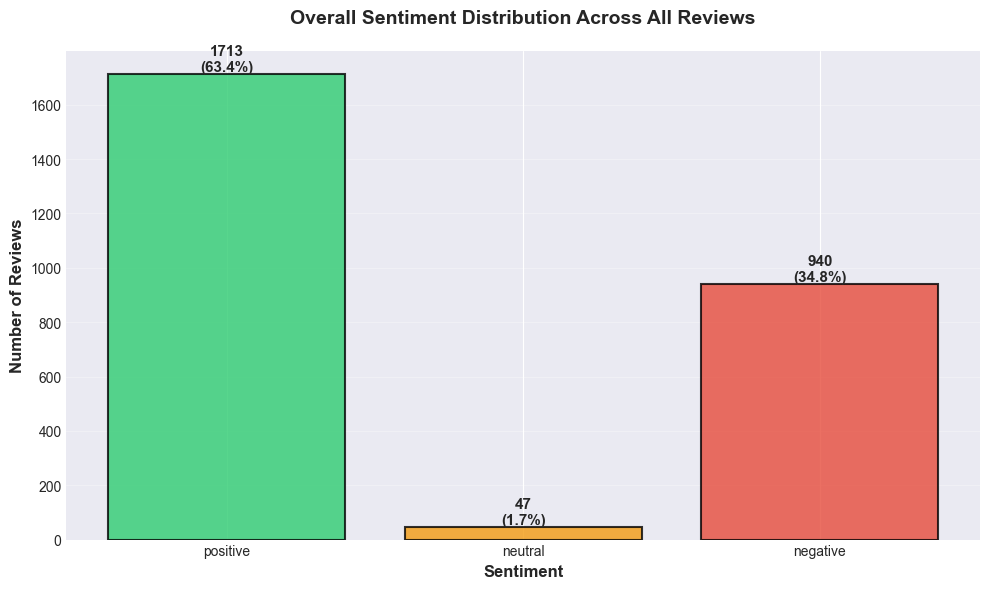


📊 Sentiment Distribution Summary:
  Positive: 1,713 reviews (63.4%)
  Neutral: 47 reviews (1.7%)
  Negative: 940 reviews (34.8%)


In [18]:
# Sentiment distribution
sentiment_counts = all_reviews['sentiment'].value_counts()
sentiment_order = ['positive', 'neutral', 'negative']
sentiment_counts = sentiment_counts.reindex(sentiment_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(sentiment_counts.index, sentiment_counts.values, 
              color=[colors.get(s, '#95a5a6') for s in sentiment_counts.index],
              alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(all_reviews)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Sentiment', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Reviews', fontsize=12, fontweight='bold')
ax.set_title('Overall Sentiment Distribution Across All Reviews', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Sentiment Distribution Summary:")
for sentiment, count in sentiment_counts.items():
    percentage = (count / len(all_reviews)) * 100
    print(f"  {sentiment.capitalize()}: {count:,} reviews ({percentage:.1f}%)")


### 13.2: Sentiment Distribution by Bank

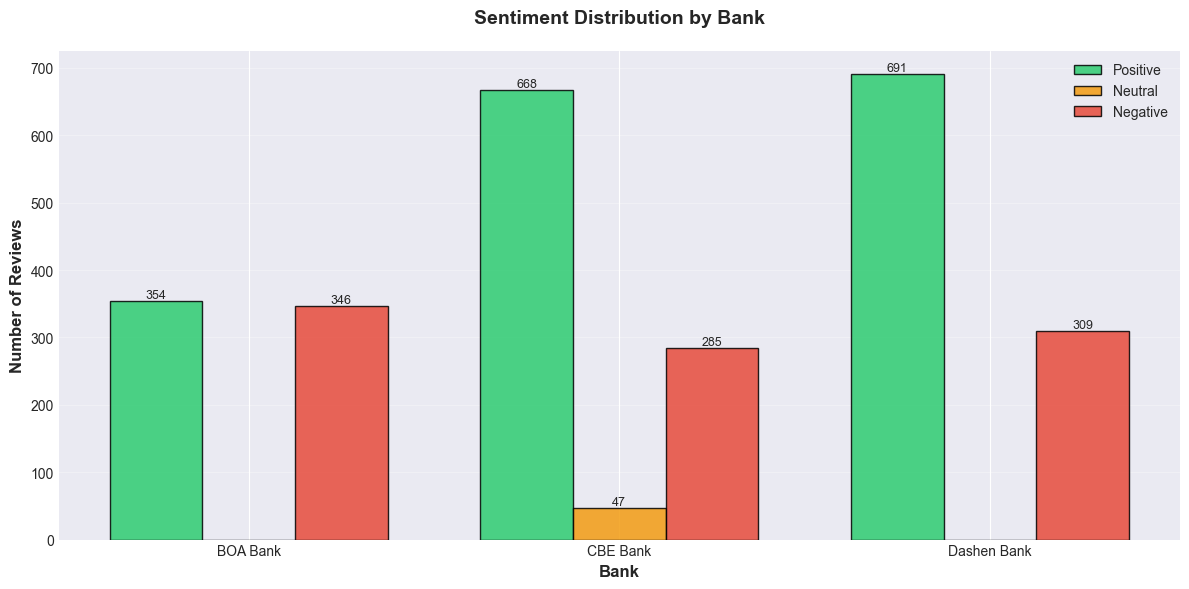


📊 Sentiment Distribution by Bank:
sentiment    positive  neutral  negative
bank                                    
BOA Bank          354        0       346
CBE Bank          668       47       285
Dashen Bank       691        0       309


In [19]:
# Sentiment by bank
sentiment_by_bank = pd.crosstab(all_reviews['bank'], all_reviews['sentiment'])
sentiment_by_bank = sentiment_by_bank.reindex(columns=sentiment_order, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(sentiment_by_bank.index))
width = 0.25

for i, sentiment in enumerate(sentiment_order):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, sentiment_by_bank[sentiment], width, 
                  label=sentiment.capitalize(), 
                  color=colors.get(sentiment, '#95a5a6'), alpha=0.85, edgecolor='black', linewidth=1)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Bank', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Reviews', fontsize=12, fontweight='bold')
ax.set_title('Sentiment Distribution by Bank', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(sentiment_by_bank.index)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Sentiment Distribution by Bank:")
print(sentiment_by_bank)


### 13.3: Top N-Grams (Most Frequent Words & Phrases)

In [ ]:
# Extract 1-grams (unigrams) - most frequent single words
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')

In [23]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\teMelkishi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

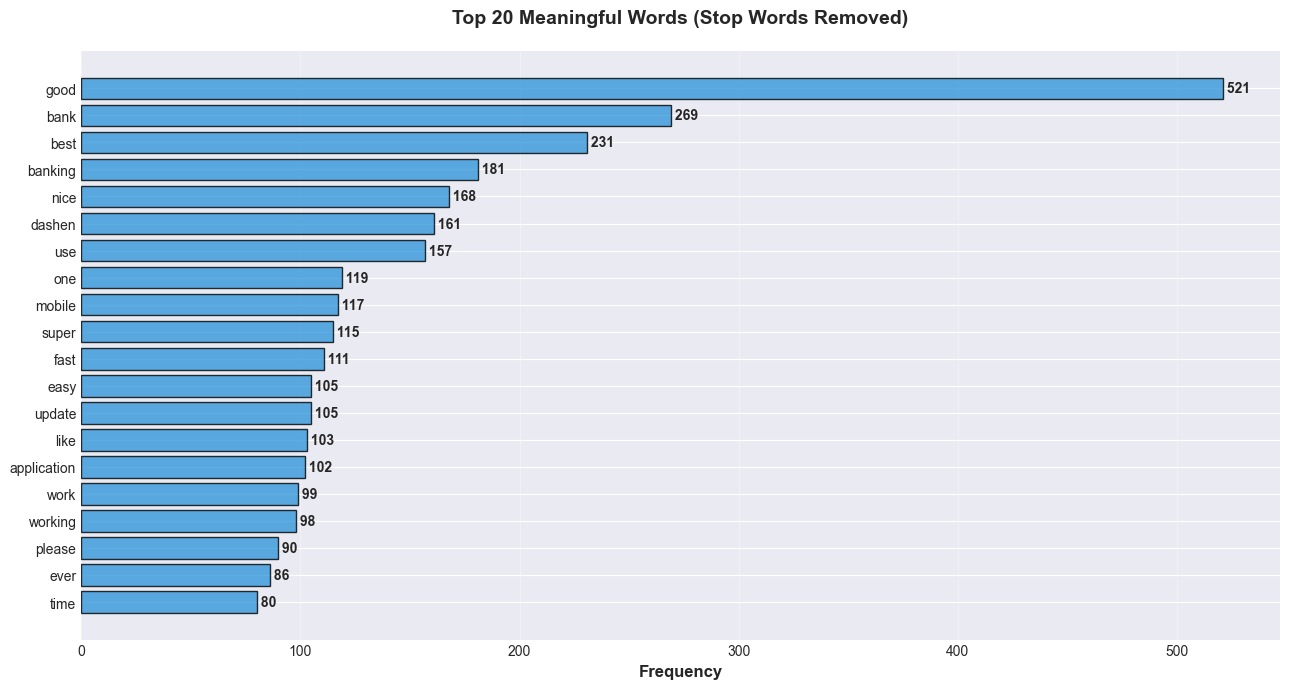


📊 Top 20 Most Frequent Words:
   1. good            :  521 occurrences
   2. bank            :  269 occurrences
   3. best            :  231 occurrences
   4. banking         :  181 occurrences
   5. nice            :  168 occurrences
   6. dashen          :  161 occurrences
   7. use             :  157 occurrences
   8. one             :  119 occurrences
   9. mobile          :  117 occurrences
  10. super           :  115 occurrences
  11. fast            :  111 occurrences
  12. easy            :  105 occurrences
  13. update          :  105 occurrences
  14. like            :  103 occurrences
  15. application     :  102 occurrences
  16. work            :   99 occurrences
  17. working         :   98 occurrences
  18. please          :   90 occurrences
  19. ever            :   86 occurrences
  20. time            :   80 occurrences


In [25]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
custom_stops = {'app', 'would', 'also', 'even'} 
stop_words.update(custom_stops)
all_words = []
for review in all_reviews['review'].dropna():
    tokens = word_tokenize(str(review).lower())
    filtered_tokens = [
        t for t in tokens 
        if len(t) > 2 and t.isalpha() and t not in stop_words
    ]
    
    all_words.extend(filtered_tokens)

word_freq = Counter(all_words)
top_20_words = dict(word_freq.most_common(20))

# --- Plotting Code Remains the Same ---
fig, ax = plt.subplots(figsize=(13, 7))
words = list(top_20_words.keys())
counts = list(top_20_words.values())

bars = ax.barh(words, counts, color='#3498db', alpha=0.8, edgecolor='black', linewidth=1)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(width)}', ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Meaningful Words (Stop Words Removed)', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Top 20 Most Frequent Words:")
for i, (word, count) in enumerate(top_20_words.items(), 1):
    print(f"  {i:2d}. {word:15} : {count:4d} occurrences")


### 13.4: Top Bigrams (Most Frequent 2-Word Phrases)

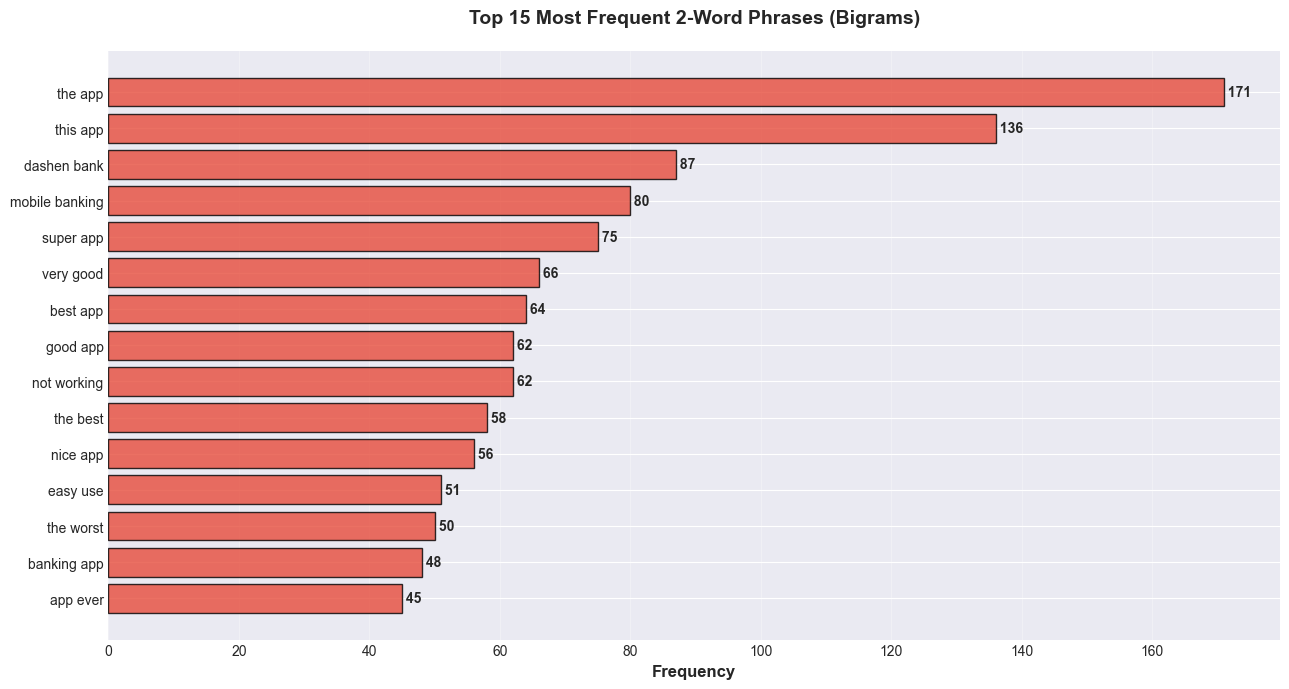


📊 Top 15 Most Frequent Bigrams:
   1. the app                   :  171 occurrences
   2. this app                  :  136 occurrences
   3. dashen bank               :   87 occurrences
   4. mobile banking            :   80 occurrences
   5. super app                 :   75 occurrences
   6. very good                 :   66 occurrences
   7. best app                  :   64 occurrences
   8. good app                  :   62 occurrences
   9. not working               :   62 occurrences
  10. the best                  :   58 occurrences
  11. nice app                  :   56 occurrences
  12. easy use                  :   51 occurrences
  13. the worst                 :   50 occurrences
  14. banking app               :   48 occurrences
  15. app ever                  :   45 occurrences


In [26]:
# Extract 2-grams (bigrams) - most frequent word pairs
from nltk.util import ngrams

all_bigrams = []
for review in all_reviews['review'].dropna():
    tokens = word_tokenize(str(review).lower())
    tokens = [t for t in tokens if len(t) > 2 and t.isalpha()]
    bigrams_list = list(ngrams(tokens, 2))
    all_bigrams.extend(bigrams_list)

bigram_freq = Counter(all_bigrams)
top_15_bigrams = dict(bigram_freq.most_common(15))

fig, ax = plt.subplots(figsize=(13, 7))
bigram_labels = [f"{word1} {word2}" for word1, word2 in top_15_bigrams.keys()]
bigram_counts = list(top_15_bigrams.values())

bars = ax.barh(bigram_labels, bigram_counts, color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(width)}', ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Most Frequent 2-Word Phrases (Bigrams)', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Top 15 Most Frequent Bigrams:")
for i, (bigram, count) in enumerate(top_15_bigrams.items(), 1):
    phrase = f"{bigram[0]} {bigram[1]}"
    print(f"  {i:2d}. {phrase:25} : {count:4d} occurrences")


### 13.5: Theme Distribution Analysis

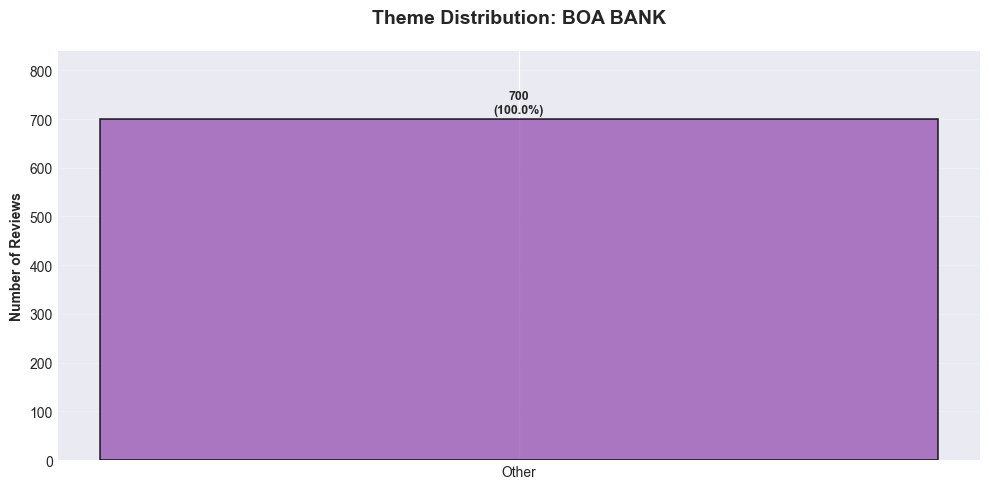


📊 BOA BANK Theme Summary:
  Other                    :  700 reviews (100.0%)
--------------------------------------------------


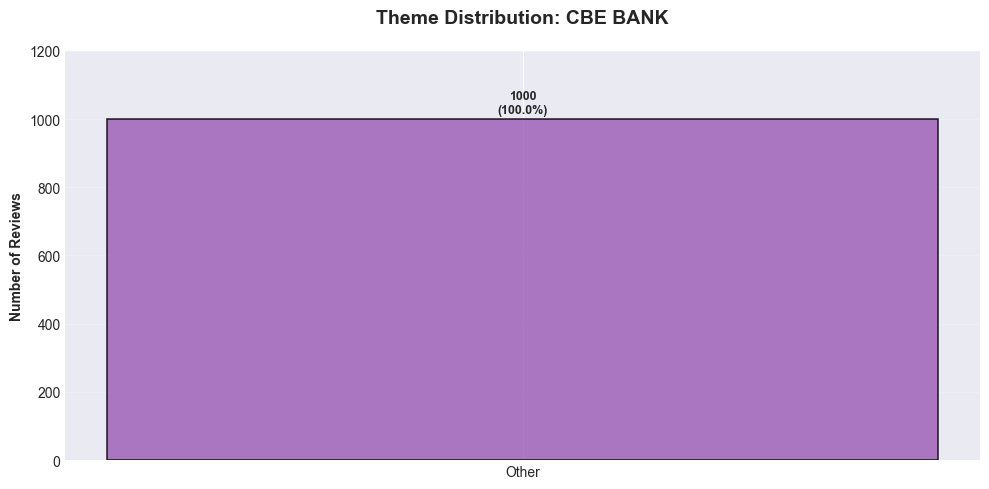


📊 CBE BANK Theme Summary:
  Other                    : 1000 reviews (100.0%)
--------------------------------------------------


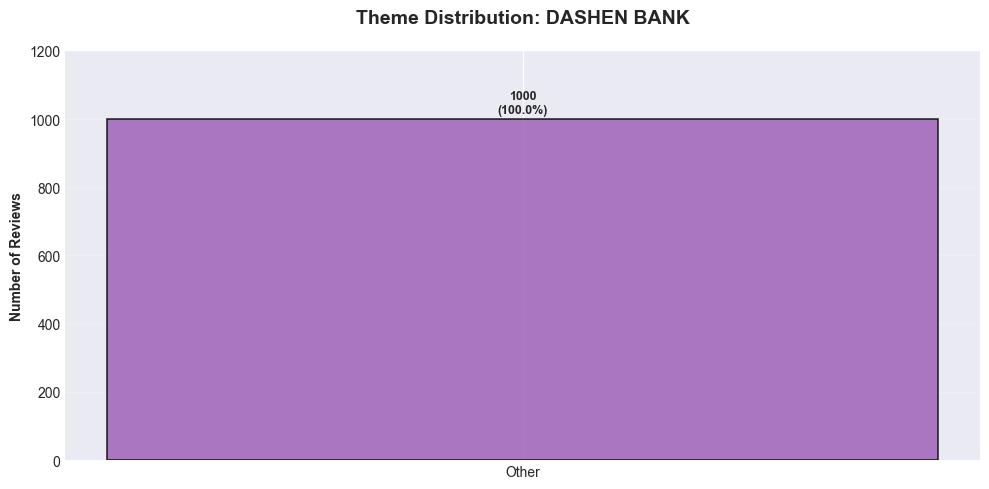


📊 DASHEN BANK Theme Summary:
  Other                    : 1000 reviews (100.0%)
--------------------------------------------------


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the Mapping Logic
# Add your granular keywords/identified_themes as keys and group them into broad categories
theme_map = {
    # Customer Support
    'customer service': 'Customer Support', 'chat support': 'Customer Support', 
    'response time': 'Customer Support', 'help desk': 'Customer Support',
    
    # App & Technical
    'app crash': 'App & Technical', 'login issue': 'App & Technical', 
    'bug': 'App & Technical', 'slow loading': 'App & Technical', 'technical': 'App & Technical',
    
    # Transaction & Fees
    'fees': 'Transaction & Fees', 'hidden charges': 'Transaction & Fees', 
    'transfer': 'Transaction & Fees', 'payment failure': 'Transaction & Fees', 
    'exchange rate': 'Transaction & Fees',
    
    # Account & Security
    'blocked account': 'Account & Security', 'kyc': 'Account & Security', 
    'verification': 'Account & Security', 'fraud': 'Account & Security', 'security': 'Account & Security',
    
    # User Experience
    'user interface': 'User Experience', 'easy to use': 'User Experience', 
    'navigation': 'User Experience', 'dark mode': 'User Experience'
}

# 2. Apply Mapping
# .get(x, 'Other') ensures that if a word isn't in our dictionary, it's labeled 'Other'
all_reviews['overarching_theme'] = all_reviews['identified_theme'].str.lower().map(theme_map).fillna('Other')

# 3. Visualization Per Bank
unique_banks = all_reviews['bank'].unique()

for bank in unique_banks:
    bank_data = all_reviews[all_reviews['bank'] == bank]
    theme_counts = bank_data['overarching_theme'].value_counts().sort_values(ascending=False)
    
    if theme_counts.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(theme_counts.index, theme_counts.values, 
                  color='#9b59b6', alpha=0.8, edgecolor='black', linewidth=1.2)

    # Add value and percentage labels
    total_bank_reviews = len(bank_data)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (max(theme_counts.values)*0.01),
                f'{int(height)}\n({height/total_bank_reviews*100:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(f'Theme Distribution: {bank.upper()}', fontsize=14, fontweight='bold', pad=20)
    ax.set_ylabel('Number of Reviews', fontweight='bold')
    ax.set_ylim(0, max(theme_counts.values) * 1.2) # Add space for labels
    ax.grid(axis='y', alpha=0.2)
    
    plt.tight_layout()
    plt.show()

    print(f"\n📊 {bank.upper()} Theme Summary:")
    for theme, count in theme_counts.items():
        print(f"  {theme:25}: {count:4d} reviews ({(count/total_bank_reviews)*100:5.1f}%)")
    print("-" * 50)

### 13.6: Sentiment Distribution by Star Rating

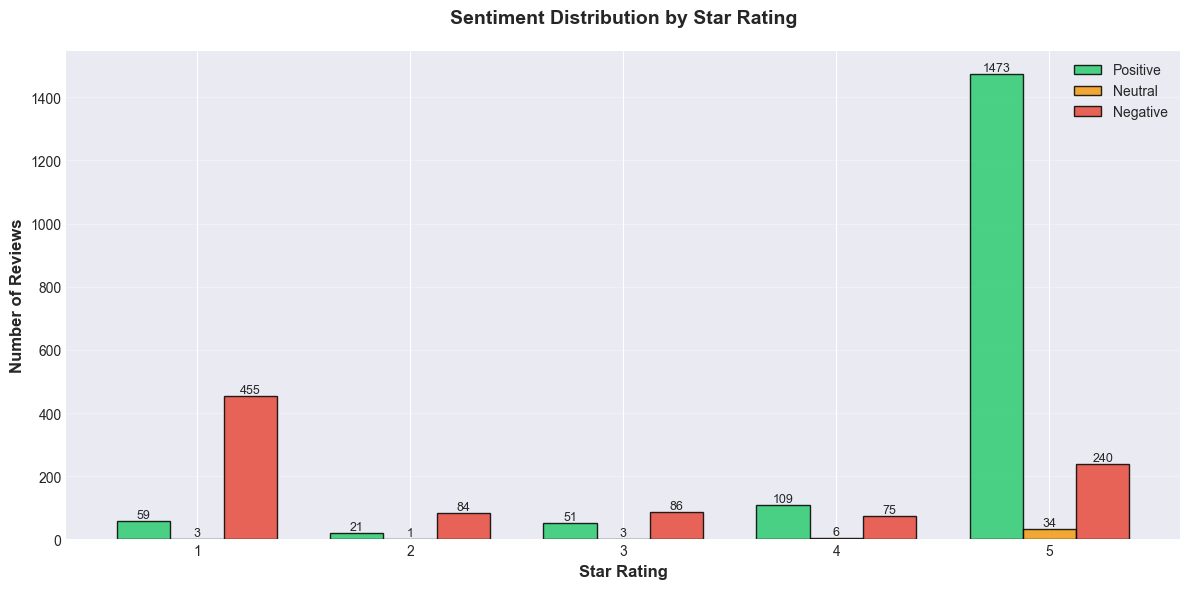


📊 Sentiment Distribution by Rating:
sentiment  positive  neutral  negative
rating                                
1                59        3       455
2                21        1        84
3                51        3        86
4               109        6        75
5              1473       34       240


In [30]:
# Sentiment by rating
if 'rating' in all_reviews.columns:
    sentiment_by_rating = pd.crosstab(all_reviews['rating'], all_reviews['sentiment'])
    sentiment_by_rating = sentiment_by_rating.reindex(columns=sentiment_order, fill_value=0)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(sentiment_by_rating.index))
    width = 0.25
    
    for i, sentiment in enumerate(sentiment_order):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, sentiment_by_rating[sentiment], width, 
                      label=sentiment.capitalize(), 
                      color=colors.get(sentiment, '#95a5a6'), alpha=0.85, edgecolor='black', linewidth=1)
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Star Rating', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Reviews', fontsize=12, fontweight='bold')
    ax.set_title('Sentiment Distribution by Star Rating', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(sorted(sentiment_by_rating.index))
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Sentiment Distribution by Rating:")
    print(sentiment_by_rating)
else:
    print("⚠️ 'rating' column not found in data")


### 13.7: Sentiment Distribution - Pie Chart

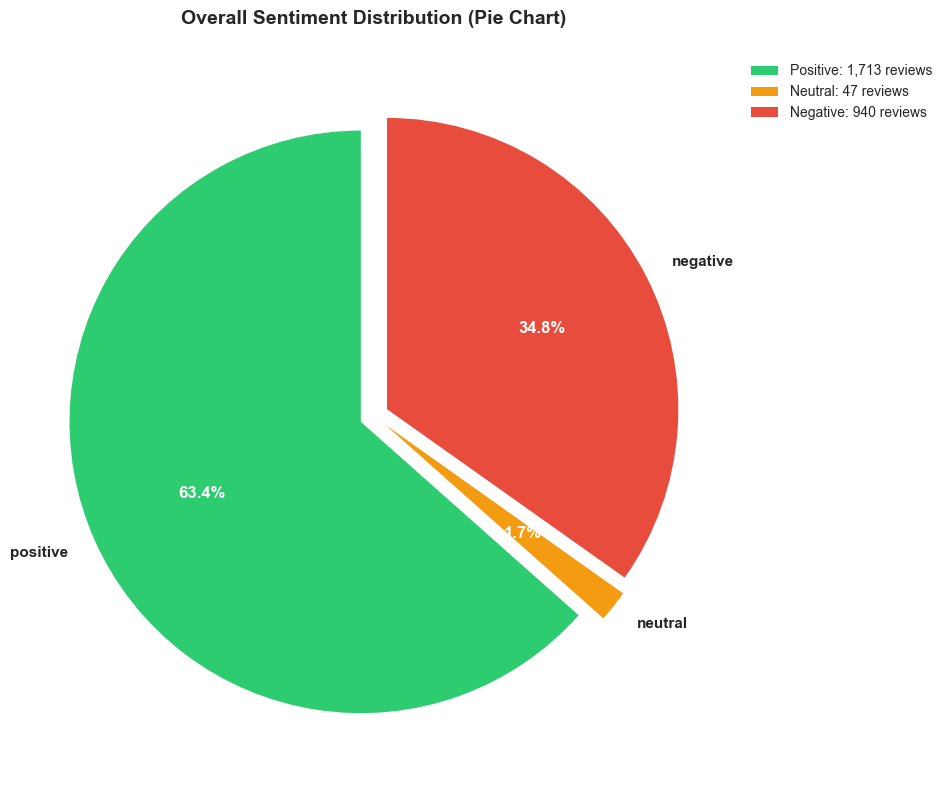

In [31]:
# Pie chart for sentiment distribution
fig, ax = plt.subplots(figsize=(10, 8))

sentiment_counts_pie = all_reviews['sentiment'].value_counts().reindex(sentiment_order, fill_value=0)
colors_pie = [colors.get(s, '#95a5a6') for s in sentiment_counts_pie.index]

wedges, texts, autotexts = ax.pie(sentiment_counts_pie.values, 
                                    labels=sentiment_counts_pie.index,
                                    autopct='%1.1f%%',
                                    colors=colors_pie,
                                    startangle=90,
                                    explode=(0.05, 0.05, 0.05),
                                    textprops={'fontsize': 11, 'fontweight': 'bold'})

# Enhance text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('Overall Sentiment Distribution (Pie Chart)', fontsize=14, fontweight='bold', pad=20)

# Add legend with counts
legend_labels = [f"{s.capitalize()}: {sentiment_counts_pie[s]:,} reviews" 
                 for s in sentiment_order]
ax.legend(legend_labels, loc='upper left', fontsize=10, bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


### 13.8: Heatmap - Sentiment by Theme

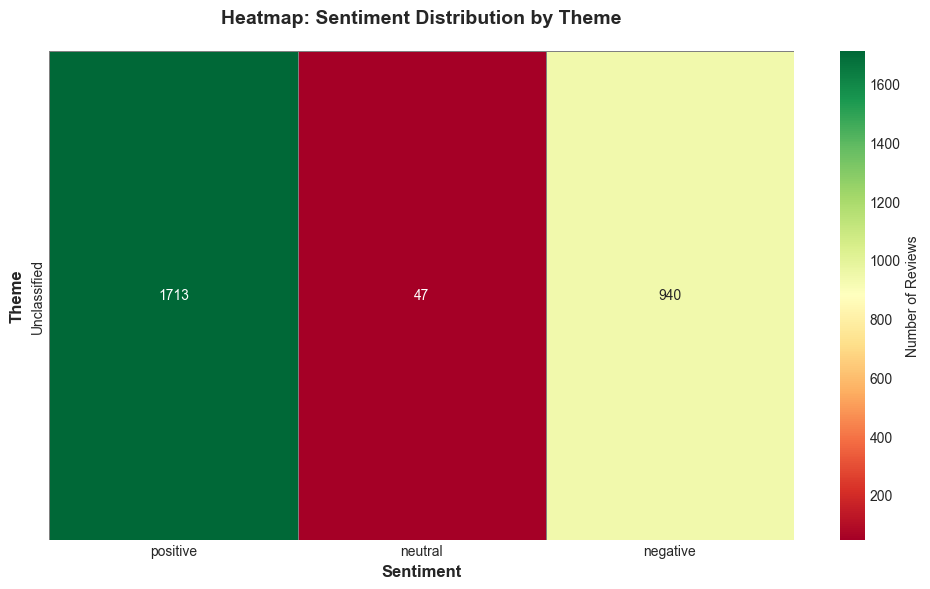


📊 Sentiment by Theme Crosstab:
sentiment         positive  neutral  negative
identified_theme                             
Unclassified          1713       47       940


In [ ]:
# Create heatmap of sentiment by theme
sentiment_theme_crosstab = pd.crosstab(all_reviews['identified_theme'], all_reviews['sentiment'])
sentiment_theme_crosstab = sentiment_theme_crosstab.reindex(columns=sentiment_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(sentiment_theme_crosstab, annot=True, fmt='d', cmap='RdYlGn', 
            cbar_kws={'label': 'Number of Reviews'}, linewidths=0.5, 
            ax=ax, linecolor='gray')

ax.set_xlabel('Sentiment', fontsize=12, fontweight='bold')
ax.set_ylabel('Theme', fontsize=12, fontweight='bold')
ax.set_title('Heatmap: Sentiment Distribution by Theme', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 Sentiment by Theme Crosstab:")
print(sentiment_theme_crosstab)


### 13.9: Top Words by Sentiment

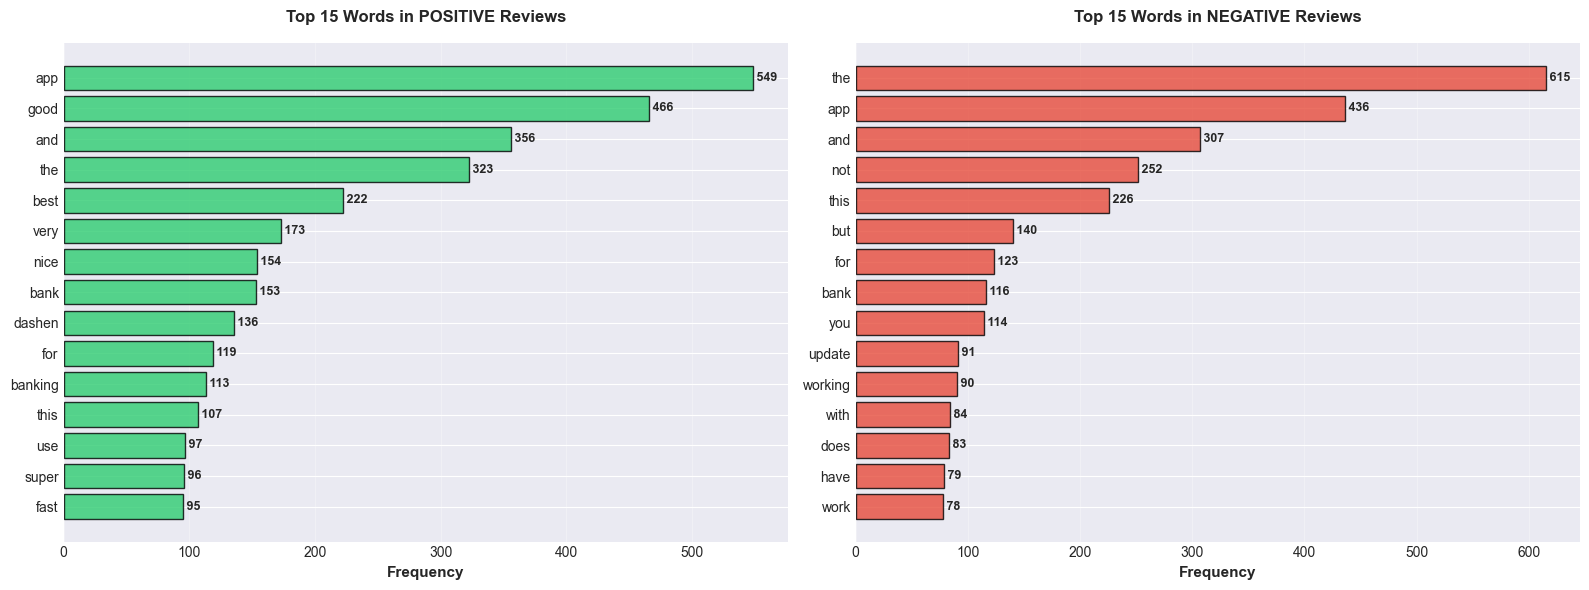


📊 Top Words Comparison:

✅ Positive Reviews Top Words:

✅ Positive Reviews - Top 10 Words:
   1. app             :  549
   2. good            :  466
   3. and             :  356
   4. the             :  323
   5. best            :  222
   6. very            :  173
   7. nice            :  154
   8. bank            :  153
   9. dashen          :  136
  10. for             :  119

❌ Negative Reviews - Top 10 Words:
   1. the             :  615
   2. app             :  436
   3. and             :  307
   4. not             :  252
   5. this            :  226
   6. but             :  140
   7. for             :  123
   8. bank            :  116
   9. you             :  114
  10. update          :   91


In [34]:
# Extract top words for positive and negative sentiments
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sentiment_pairs = [('positive', axes[0], '#2ecc71'), ('negative', axes[1], '#e74c3c')]

for sentiment_type, ax, color in sentiment_pairs:
    sentiment_reviews = all_reviews[all_reviews['sentiment'] == sentiment_type]['review']
    
    sentiment_words = []
    for review in sentiment_reviews.dropna():
        tokens = word_tokenize(str(review).lower())
        sentiment_words.extend([t for t in tokens if len(t) > 2 and t.isalpha()])
    
    sentiment_freq = Counter(sentiment_words)
    top_words = dict(sentiment_freq.most_common(15))
    
    words = list(top_words.keys())
    counts = list(top_words.values())
    
    bars = ax.barh(words, counts, color=color, alpha=0.8, edgecolor='black', linewidth=1)
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
                f' {int(width)}', ha='left', va='center', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'Top 15 Words in {sentiment_type.upper()} Reviews', 
                 fontsize=12, fontweight='bold', pad=15)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Top Words Comparison:")
print(f"\n✅ Positive Reviews Top Words:")
for i, (word, count) in enumerate(dict(Counter(sentiment_reviews).most_common(10)).items() if sentiment_type == 'positive' else [], 1):
    pass

# Recompute for proper display
positive_words = []
negative_words = []

for sentiment_type, words_list in [('positive', positive_words), ('negative', negative_words)]:
    sentiment_reviews = all_reviews[all_reviews['sentiment'] == sentiment_type]['review']
    for review in sentiment_reviews.dropna():
        tokens = word_tokenize(str(review).lower())
        words_list.extend([t for t in tokens if len(t) > 2 and t.isalpha()])

print("\n✅ Positive Reviews - Top 10 Words:")
for i, (word, count) in enumerate(Counter(positive_words).most_common(10), 1):
    print(f"  {i:2d}. {word:15} : {count:4d}")

print("\n❌ Negative Reviews - Top 10 Words:")
for i, (word, count) in enumerate(Counter(negative_words).most_common(10), 1):
    print(f"  {i:2d}. {word:15} : {count:4d}")
